# Download data from kaggle

In [ ]:
# configuring the path of Kaggle.json file
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
# API to fetch the dataset from Kaggle
!kaggle datasets download -d omkargurav/face-mask-dataset

Dataset URL: https://www.kaggle.com/datasets/omkargurav/face-mask-dataset
License(s): unknown
face-mask-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
# extracting the compessed Dataset
from zipfile import ZipFile
dataset = '/content/face-mask-dataset.zip'

with ZipFile(dataset,'r') as zip:
  zip.extractall()
  print('The dataset is extracted')

The dataset is extracted


In [ ]:
!ls

data  face-mask-dataset.zip  kaggle.json  sample_data


# import Libraries

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
from sklearn.model_selection import train_test_split

# Read data

In [ ]:
with_mask_files = os.listdir('/content/data/with_mask')
without_mask_files = os.listdir('/content/data/without_mask')

In [ ]:
print(f'The length of files with mask = {len(with_mask_files)}')
print(f'The length of files without mask = {len(without_mask_files)}')

The length of files with mask = 3725
The length of files without mask = 3828


In [ ]:
with_mask_files[10:16]


['with_mask_3639.jpg',
 'with_mask_1274.jpg',
 'with_mask_1087.jpg',
 'with_mask_978.jpg',
 'with_mask_2943.jpg',
 'with_mask_2916.jpg']

In [ ]:
without_mask_files[10:16]

['without_mask_1938.jpg',
 'without_mask_1675.jpg',
 'without_mask_1582.jpg',
 'without_mask_2194.jpg',
 'without_mask_3472.jpg',
 'without_mask_2816.jpg']

# Displaying images

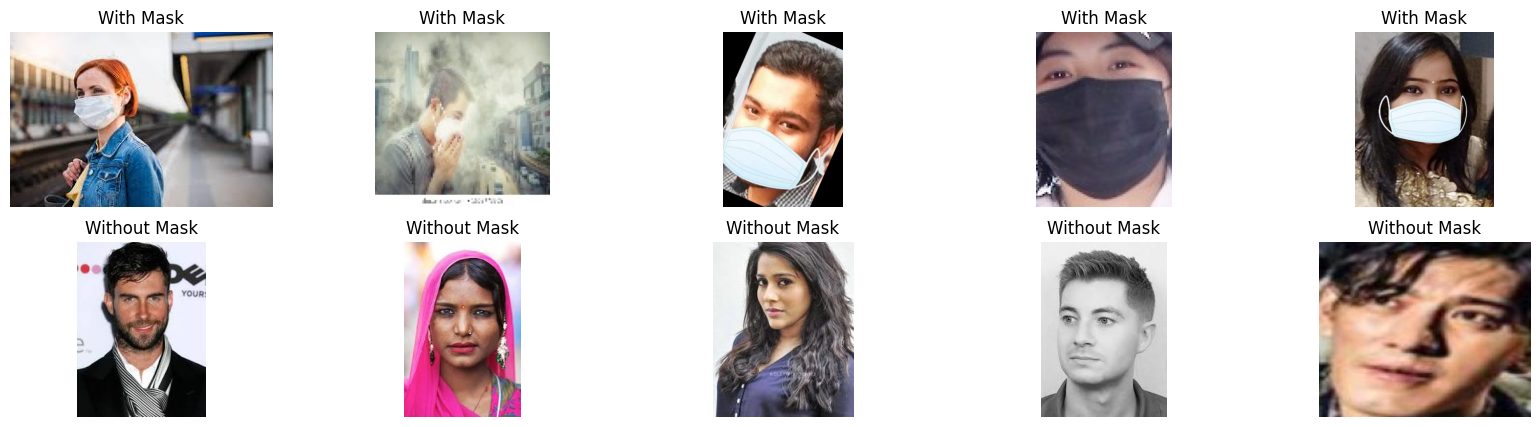

In [ ]:
with_mask_path = "/content/data/with_mask"
without_mask_path = "/content/data/without_mask"

with_mask_files = [f for f in os.listdir(with_mask_path) if os.path.isfile(os.path.join(with_mask_path, f))]
without_mask_files = [f for f in os.listdir(without_mask_path) if os.path.isfile(os.path.join(without_mask_path, f))]

sample_with = with_mask_files[:5]
sample_without = without_mask_files[:5]

plt.figure(figsize=(20, 5))

for i, file in enumerate(sample_with):
    img_path = os.path.join(with_mask_path, file)
    img = Image.open(img_path)

    plt.subplot(2, 5, i+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title("With Mask")

for i, file in enumerate(sample_without):
    img_path = os.path.join(without_mask_path, file)
    img = Image.open(img_path)

    plt.subplot(2, 5, i+6)
    plt.imshow(img)
    plt.axis("off")
    plt.title("Without Mask")

plt.show()



# Create Labels For images

In [ ]:
with_mask_label=[1]*len(with_mask_files)
without_mask_label=[0]*len(without_mask_files)

In [ ]:
with_mask_label[0:5]

[1, 1, 1, 1, 1]

In [ ]:
without_mask_label[0:5]

[0, 0, 0, 0, 0]

In [ ]:
lables=with_mask_label+without_mask_label

# Preprocessing images

### Resize images
### Convert the images to numpy array

In [ ]:
with_mask_path = '/content/data/with_mask/'
data=[]

for img_file in with_mask_files:
  image=Image.open(with_mask_path+img_file)
  image=image.resize((128,128))
  image = image.convert('RGB')
  image=np.array(image)
  data.append(image)

without_mask_path = '/content/data/without_mask/'
for img_file in without_mask_files:

  image = Image.open(without_mask_path + img_file)
  image = image.resize((128,128))
  image = image.convert('RGB')
  image = np.array(image)
  data.append(image)

/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [ ]:
type(data)

list

In [ ]:
len(data)

7553

array([[[223, 222, 223],
        [227, 224, 225],
        [232, 229, 229],
        ...,
        [ 28,  21,  33],
        [ 36,  27,  33],
        [ 49,  40,  39]],

       [[223, 222, 223],
        [227, 224, 225],
        [232, 229, 229],
        ...,
        [107,  86,  65],
        [ 81,  65,  53],
        [ 67,  60,  60]],

       [[223, 222, 223],
        [227, 224, 225],
        [232, 228, 229],
        ...,
        [190, 154, 104],
        [142, 119,  92],
        [105, 100, 103]],

       ...,

       [[ 36,  30,  32],
        [ 36,  30,  32],
        [ 36,  30,  32],
        ...,
        [117, 109, 107],
        [113, 106, 104],
        [109, 104, 101]],

       [[ 34,  28,  30],
        [ 34,  28,  30],
        [ 34,  28,  30],
        ...,
        [115, 107, 105],
        [111, 105, 102],
        [109, 104, 101]],

       [[ 32,  26,  28],
        [ 32,  26,  28],
        [ 32,  26,  28],
        ...,
        [113, 105, 103],
        [110, 103, 101],
        [108, 103, 100]]], dtype=uint8)
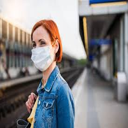

In [ ]:
data[0]


In [ ]:
# turn data and labels to numpy array

X=np.array(data)
Y=np.array(lables)

In [ ]:
type(X)

numpy.ndarray

In [ ]:
type(Y)

numpy.ndarray

In [ ]:
print(X.shape)
print(Y.shape)

(7553, 128, 128, 3)
(7553,)


# Train Test Split

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=2)

In [ ]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(6042, 128, 128, 3)
(1511, 128, 128, 3)
(6042,)
(1511,)


In [ ]:
# scaling the data

X_train_scaled = x_train/255

X_test_scaled = x_test/255

array([[[207, 207, 219],
        [224, 224, 233],
        [224, 219, 226],
        ...,
        [218, 216, 229],
        [214, 212, 222],
        [217, 218, 219]],

       [[205, 207, 215],
        [228, 217, 228],
        [231, 231, 236],
        ...,
        [226, 222, 229],
        [216, 208, 213],
        [219, 223, 222]],

       [[217, 212, 219],
        [223, 229, 232],
        [222, 215, 222],
        ...,
        [224, 221, 220],
        [235, 226, 225],
        [223, 222, 222]],

       ...,

       [[ 99, 106,  95],
        [ 99, 106,  98],
        [ 99, 103,  99],
        ...,
        [152, 150, 166],
        [148, 150, 164],
        [177, 182, 194]],

       [[ 90, 108,  96],
        [ 91, 105,  96],
        [ 82,  90,  87],
        ...,
        [172, 170, 181],
        [203, 204, 212],
        [226, 232, 235]],

       [[ 94, 117, 104],
        [ 89, 106,  98],
        [ 79,  89,  86],
        ...,
        [152, 147, 154],
        [191, 189, 190],
        [232, 238, 238]]], dtype=uint8)
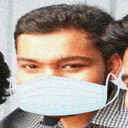

In [ ]:
x_train[0]

In [ ]:
X_train_scaled[0]

array([[[0.81176471, 0.81176471, 0.85882353],
        [0.87843137, 0.87843137, 0.91372549],
        [0.87843137, 0.85882353, 0.88627451],
        ...,
        [0.85490196, 0.84705882, 0.89803922],
        [0.83921569, 0.83137255, 0.87058824],
        [0.85098039, 0.85490196, 0.85882353]],

       [[0.80392157, 0.81176471, 0.84313725],
        [0.89411765, 0.85098039, 0.89411765],
        [0.90588235, 0.90588235, 0.9254902 ],
        ...,
        [0.88627451, 0.87058824, 0.89803922],
        [0.84705882, 0.81568627, 0.83529412],
        [0.85882353, 0.8745098 , 0.87058824]],

       [[0.85098039, 0.83137255, 0.85882353],
        [0.8745098 , 0.89803922, 0.90980392],
        [0.87058824, 0.84313725, 0.87058824],
        ...,
        [0.87843137, 0.86666667, 0.8627451 ],
        [0.92156863, 0.88627451, 0.88235294],
        [0.8745098 , 0.87058824, 0.87058824]],

       ...,

       [[0.38823529, 0.41568627, 0.37254902],
        [0.38823529, 0.41568627, 0.38431373],
        [0.38823529, 0

# Build CNN

In [ ]:
import tensorflow as tf
from tensorflow import keras


In [ ]:
num_of_classes=2
model=keras.Sequential()

model.add(keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(128,128,3)))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(keras.layers.Flatten())

model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.Dense(64, activation='relu'))
model.add(keras.layers.Dropout(0.5))


model.add(keras.layers.Dense(num_of_classes, activation='sigmoid'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Compile NN

In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['acc'])

# Train the NN

In [ ]:
history = model.fit(X_train_scaled, y_train, validation_split=0.1, epochs=5)

Epoch 1/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - acc: 0.7216 - loss: 0.5814 - val_acc: 0.8959 - val_loss: 0.2926
Epoch 2/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - acc: 0.8856 - loss: 0.2898 - val_acc: 0.9008 - val_loss: 0.2286
Epoch 3/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - acc: 0.9071 - loss: 0.2292 - val_acc: 0.9339 - val_loss: 0.1840
Epoch 4/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - acc: 0.9237 - loss: 0.1872 - val_acc: 0.9322 - val_loss: 0.1826
Epoch 5/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - acc: 0.9510 - loss: 0.1466 - val_acc: 0.9289 - val_loss: 0.1828


# Model Evaluaton

In [ ]:
loss,accurecy=model.evaluate(X_test_scaled,y_test)
print(f'The loss is {loss}')
print(f'The accuracy is {accurecy}')


48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - acc: 0.9227 - loss: 0.2488
The loss is 0.2226627916097641
The accuracy is 0.929847776889801


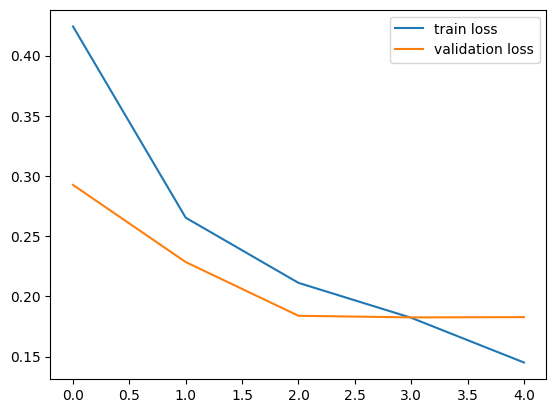

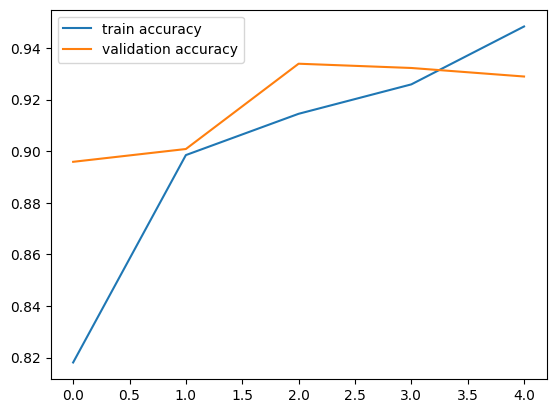

In [ ]:
h = history

# plot the loss value
plt.plot(h.history['loss'], label='train loss')
plt.plot(h.history['val_loss'], label='validation loss')
plt.legend()
plt.show()

# plot the accuracy value
plt.plot(h.history['acc'], label='train accuracy')
plt.plot(h.history['val_acc'], label='validation accuracy')
plt.legend()
plt.show()

# Predictive System

Path of the image to be predicted: /content/download.png


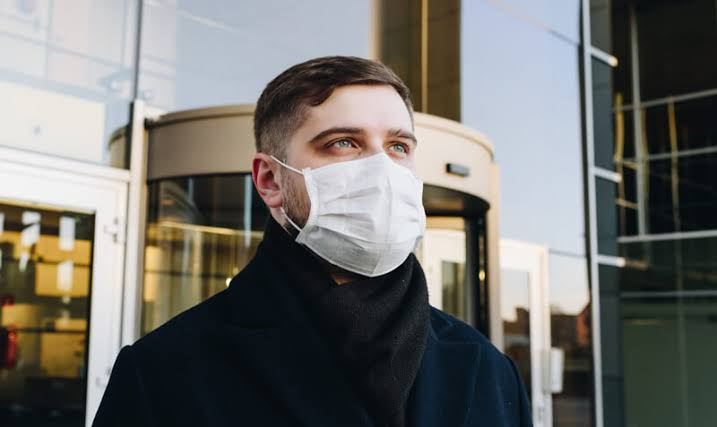

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
[[0.30200306 0.8334847 ]]
1
The person in the image is wearing a mask


In [ ]:
input_image_path = input('Path of the image to be predicted: ')

input_image = cv2.imread(input_image_path)

cv2_imshow(input_image)

input_image_resized = cv2.resize(input_image, (128,128))

input_image_scaled = input_image_resized/255

input_image_reshaped = np.reshape(input_image_scaled, [1,128,128,3])

input_prediction = model.predict(input_image_reshaped)

print(input_prediction)


input_pred_label = np.argmax(input_prediction)

print(input_pred_label)

# 'with_mask_1274.jpg'
if input_pred_label == 1:

  print('The person in the image is wearing a mask')

else:

  print('The person in the image is not wearing a mask')

Path of the image to be predicted: /content/download (1).png


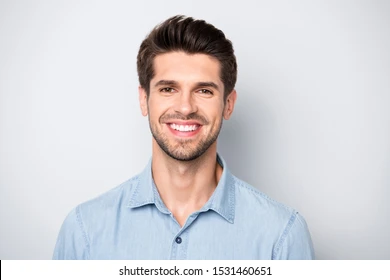

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
[[0.51796293 0.5328624 ]]
1
The person in the image is wearing a mask


In [ ]:
input_image_path = input('Path of the image to be predicted: ')

input_image = cv2.imread(input_image_path)

cv2_imshow(input_image)

input_image_resized = cv2.resize(input_image, (128,128))

input_image_scaled = input_image_resized/255

input_image_reshaped = np.reshape(input_image_scaled, [1,128,128,3])

input_prediction = model.predict(input_image_reshaped)

print(input_prediction)


input_pred_label = np.argmax(input_prediction)

print(input_pred_label)


if input_pred_label == 1:

  print('The person in the image is wearing a mask')

else:

  print('The person in the image is not wearing a mask')

# Save the model

In [ ]:
model.save("mask_model.h5")
